In [1]:
!pip install textblob -q


In [2]:
from textblob import TextBlob

def analyze_sentiment():
    print("--- Real-Time Sentiment Analyzer ---")
    print("Type any sentence to analyze.")
    print("Type 'exit' to quit.\n")

    while True:
        user_input = input("Enter Text: ")

        if user_input.lower().strip() == "exit":
            print("Exiting Analyzer.")
            break

        if not user_input.strip():
            continue

        # Analyze text using TextBlob
        blob = TextBlob(user_input)

        polarity = blob.sentiment.polarity
        subjectivity = blob.sentiment.subjectivity

        # Determine sentiment
        if polarity > 0.1:
            sentiment_label = "POSITIVE 🙂"
        elif polarity < -0.1:
            sentiment_label = "NEGATIVE 🙁"
        else:
            sentiment_label = "NEUTRAL 😐"

        print(f" -> Sentiment: {sentiment_label}")
        print(f" -> Polarity: {polarity:.2f}")
        print(f" -> Subjectivity: {subjectivity:.2f}")
        print()

# Start analyzer
analyze_sentiment()

--- Real-Time Sentiment Analyzer ---
Type any sentence to analyze.
Type 'exit' to quit.

Enter Text: i love you
 -> Sentiment: POSITIVE 🙂
 -> Polarity: 0.50
 -> Subjectivity: 0.60

Enter Text: i want to kill you
 -> Sentiment: NEUTRAL 😐
 -> Polarity: 0.00
 -> Subjectivity: 0.00

Enter Text: i have crush on a girl
 -> Sentiment: NEUTRAL 😐
 -> Polarity: 0.00
 -> Subjectivity: 0.00

Enter Text: mam is so good in teaching 
 -> Sentiment: POSITIVE 🙂
 -> Polarity: 0.70
 -> Subjectivity: 0.60



KeyboardInterrupt: Interrupted by user

In [3]:
!pip install spacy -q
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 80.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
import spacy

# Load spaCy's English model
nlp = spacy.load("en_core_web_sm")

# Sample unstructured text
raw_resume_text = """
Rahul Sharma is a Software Developer living in New Delhi.
He worked at Google for 3 years starting from March 2021.
Rahul graduated from Delhi University and has expertise in Python,
Machine Learning and AWS.
"""

print("Processing text with spaCy...\n")

# Process the text
doc = nlp(raw_resume_text)

# Extract Named Entities
print("--- Extracted Named Entities ---")

for ent in doc.ents:
    print(
        f"Entity: {ent.text:<20} | "
        f"Type: {ent.label_:<10} "
        f"({spacy.explain(ent.label_)})"
    )

# Extract nouns and proper nouns
print("\n--- Identified Keywords/Nouns ---")

nouns = [
    token.text
    for token in doc
    if token.pos_ in ["NOUN", "PROPN"]
]

print("Key Nouns Found:", list(set(nouns)))

Processing text with spaCy...

--- Extracted Named Entities ---
Entity: Rahul Sharma         | Type: PERSON     (People, including fictional)
Entity: Software             | Type: ORG        (Companies, agencies, institutions, etc.)
Entity: New Delhi            | Type: GPE        (Countries, cities, states)
Entity: Google               | Type: ORG        (Companies, agencies, institutions, etc.)
Entity: 3 years              | Type: DATE       (Absolute or relative dates or periods)
Entity: March 2021           | Type: DATE       (Absolute or relative dates or periods)
Entity: Delhi University     | Type: ORG        (Companies, agencies, institutions, etc.)
Entity: Python               | Type: GPE        (Countries, cities, states)
Entity: Machine Learning     | Type: PERSON     (People, including fictional)

--- Identified Keywords/Nouns ---
Key Nouns Found: ['AWS', 'years', 'expertise', 'Developer', 'March', 'University', 'Software', 'Delhi', 'Machine', 'Sharma', 'Learning', 'New', 'Ra

In [5]:
!pip install scikit-learn -q

In [6]:


from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB


training_sentences = [
    "Claim your free gift card worth $1000 now",
    "URGENT! You have won a lottery, click here to claim",
    "Win cash prizes and free bonuses today",
    "Hey, are we still meeting for group study at 5 PM?",
    "Please find attached the project submission document",
    "Can you share the lecture notes for tomorrow's class?"
]

labels = [
    "Spam",
    "Spam",
    "Spam",
    "Ham",
    "Ham",
    "Ham"
]


vectorizer = CountVectorizer()

X_train = vectorizer.fit_transform(training_sentences)



classifier = MultinomialNB()

classifier.fit(X_train, labels)

print("Spam Detector Model Trained Successfully!")
print()



test_messages = [
    "Congratulations! You won a free prize call now",
    "Hey Rahul, let's complete the lab assignment tonight"
]

# Convert test messages into numerical features
X_test = vectorizer.transform(test_messages)


predictions = classifier.predict(X_test)

for message, prediction in zip(test_messages, predictions):

    print("Message:", message)
    print("Prediction:", prediction)
    print("-" * 50)

Spam Detector Model Trained Successfully!

Message: Congratulations! You won a free prize call now
Prediction: Spam
--------------------------------------------------
Message: Hey Rahul, let's complete the lab assignment tonight
Prediction: Ham
--------------------------------------------------


In [7]:
import random
from collections import defaultdict


text = "the cat sat on the mat and the dog sat on the rug"

words = text.split()

print("Words:")
print(words)
print()



model = defaultdict(list)

for i in range(len(words) - 1):
    current_word = words[i]
    next_word = words[i + 1]

    model[current_word].append(next_word)

print("Word Prediction Model:")
print(dict(model))
print()


current = "the"

output = [current]

for _ in range(5):

    # Find possible next words
    possible_next_words = model[current]

    # Randomly select the next word
    next_word = random.choice(possible_next_words)

    # Add word to output
    output.append(next_word)

    # Move to next word
    current = next_word


print("Generated text:")
print(" ".join(output))

Words:
['the', 'cat', 'sat', 'on', 'the', 'mat', 'and', 'the', 'dog', 'sat', 'on', 'the', 'rug']

Word Prediction Model:
{'the': ['cat', 'mat', 'dog', 'rug'], 'cat': ['sat'], 'sat': ['on', 'on'], 'on': ['the', 'the'], 'mat': ['and'], 'and': ['the'], 'dog': ['sat']}

Generated text:
the dog sat on the rug


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



Everyone has some hobbies that make their free time enjoyable and meaningful.
My hobbies are working out at the gym, playing volleyball, watching movies,
and photography. I usually spend about one hour working out in the gym.
I enjoy exercising because it helps me stay physically fit, active, and
disciplined. It also makes me feel fresh and energetic. Another hobby I enjoy
is playing volleyball. I like playing it with my friends because it is an
exciting team sport that improves my coordination, communication, and teamwork
skills. I also enjoy watching movies, especially horror, adventure, and
science-fiction movies. Horror movies are interesting because of their
suspense and unexpected moments, while adventure movies take me into exciting
and imaginary worlds. I particularly enjoy science-fiction movies because
they allow me to explore ideas about technology, space, the future, and
scientific discoveries. Photography is another hobby that I really enjoy.
I like capturing beautiful pl

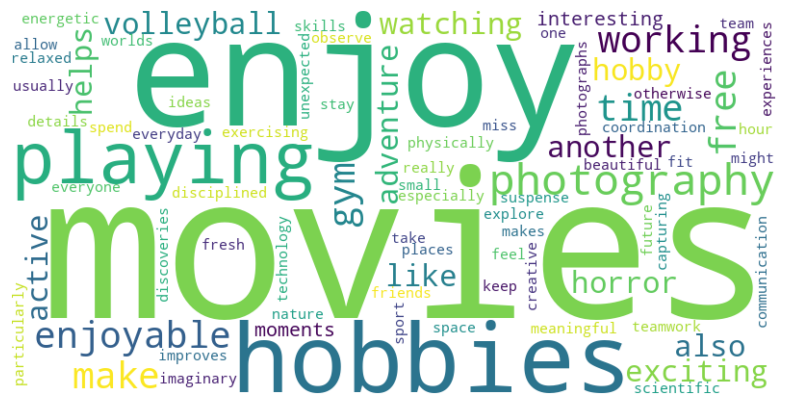

In [8]:
!pip install wordcloud -q


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter




nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')



text = """
Everyone has some hobbies that make their free time enjoyable and meaningful.
My hobbies are working out at the gym, playing volleyball, watching movies,
and photography. I usually spend about one hour working out in the gym.
I enjoy exercising because it helps me stay physically fit, active, and
disciplined. It also makes me feel fresh and energetic. Another hobby I enjoy
is playing volleyball. I like playing it with my friends because it is an
exciting team sport that improves my coordination, communication, and teamwork
skills. I also enjoy watching movies, especially horror, adventure, and
science-fiction movies. Horror movies are interesting because of their
suspense and unexpected moments, while adventure movies take me into exciting
and imaginary worlds. I particularly enjoy science-fiction movies because
they allow me to explore ideas about technology, space, the future, and
scientific discoveries. Photography is another hobby that I really enjoy.
I like capturing beautiful places, interesting moments, nature, and everyday
experiences through photographs. Photography helps me observe small details
that I might otherwise miss. These hobbies keep me active, creative, and
relaxed, and they make my free time more enjoyable.
"""

print(text)




words = word_tokenize(text.lower())

print("\nAll Words:")
print(words)



stop_words = set(stopwords.words('english'))

filtered_words = [
    word
    for word in words
    if word.isalpha() and word not in stop_words
]

print("\nFiltered Words:")
print(filtered_words)




word_freq = Counter(filtered_words)

print("\nWord Frequencies:")
print(word_freq)



wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(word_freq)



plt.figure(figsize=(10, 5))

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis('off')

plt.show()


